Imports and data


In [2]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# DAT_FILE   = r'E:\Datos TFM\Good\Good\datas002.dat'
DAT_FILE   = r'E:\Datos TFM\Bad\Bad\datas016.dat'
PSIPM_FILE = r'E:\Datos TFM\psipm.tsv'

MAX_EVENTS = 2_000_000   # leer todos; pon un número menor para pruebas rápidas



Analisis del atchivo psimp.tsv

In [3]:
x_pos = {}   # {ich (int) : x en mm (float)}
y_pos = {}   # {ich (int) : y en mm (float)}

with open(PSIPM_FILE, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()          # separa por cualquier espacio/tab
        ich   = int(parts[0])
        x     = float(parts[1])
        y     = float(parts[2])
        x_pos[ich] = x
        y_pos[ich] = y

print(f'SiPMs cargados: {len(x_pos)}')
print(f'X rango: [{min(x_pos.values()):.1f}, {max(x_pos.values()):.1f}] mm')
print(f'Y rango: [{min(y_pos.values()):.1f}, {max(y_pos.values()):.1f}] mm')
print()
print('Primeros 5:')
for ich in sorted(x_pos)[:5]:
    print(f'  Ich={ich:2d}  x={x_pos[ich]:7.2f} mm  y={y_pos[ich]:7.2f} mm')


SiPMs cargados: 61
X rango: [-13.0, 13.0] mm
Y rango: [-15.0, 15.0] mm

Primeros 5:
  Ich= 0  x=   3.25 mm  y=  -1.88 mm
  Ich= 2  x=  -0.00 mm  y=   7.50 mm
  Ich= 3  x=   6.50 mm  y=  -7.50 mm
  Ich= 4  x=  -0.00 mm  y= -15.00 mm
  Ich= 5  x=   9.75 mm  y=  -1.88 mm


Text(0.5, 1.0, 'Positions of every single SiPM')

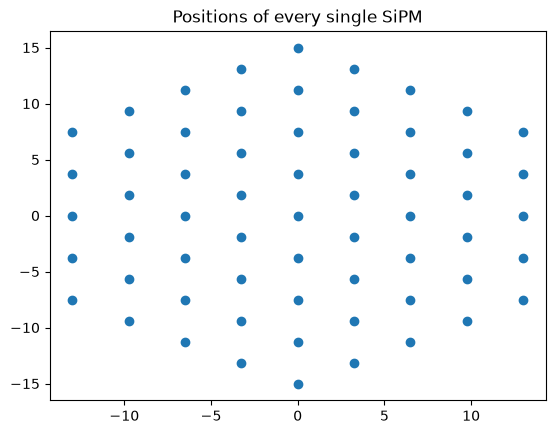

In [4]:
x_pos_sorted=dict(sorted(x_pos.items()))
y_pos_sorted=dict(sorted(y_pos.items()))

plt.figure()
plt.scatter(x_pos_sorted.values(),y_pos_sorted.values())
plt.title("Positions of every single SiPM")

In [5]:
all_charges  = []   # lista de arrays: all_charges[i]  = cargas del evento i
all_channels = []   # lista de arrays: all_channels[i] = canales del evento i

with open(DAT_FILE, 'rb') as f:
    while len(all_charges) < MAX_EVENTS:

        # — leer Nint —
        b = f.read(1)
        if not b:
            break                              # fin de archivo
        nint = struct.unpack('B', b)[0]        # 'B' = unsigned byte
        if nint == 0:
            continue                           # evento vacío, saltar

        # — leer los Nint pares (Rch, Ich) —
        charges  = []
        channels = []
        ok = True

        for _ in range(nint):
            rch_bytes = f.read(4)
            ich_bytes = f.read(4)
            if len(rch_bytes) < 4 or len(ich_bytes) < 4:
                ok = False
                break                          # archivo truncado
            rch = struct.unpack('<f', rch_bytes)[0]   # '<f' = float32 little-endian
            ich = struct.unpack('<i', ich_bytes)[0]   # '<i' = int32  little-endian
            charges.append(rch)
            channels.append(ich)

        if ok:
            all_charges.append(np.array(charges,  dtype=np.float32))
            all_channels.append(np.array(channels, dtype=np.int32))

n_events = len(all_charges)
print(f'Eventos leídos: {n_events:,}')
print()
print('Ejemplo — evento 0:')
print(f'  Nint     = {len(all_channels[0])}')
print(f'  Canales  = {all_channels[0]}')
print(f'  Cargas   = {np.round(all_charges[0], 1)}')
print(f'  RchT     = {all_charges[0].sum():.1f}')



Eventos leídos: 1,046,293

Ejemplo — evento 0:
  Nint     = 12
  Canales  = [14  7 10  8  5  0 62 12  9  3 38 15]
  Cargas   = [ 6.4  4.2  3.3  2.9  1.8  1.7  1.4  1.   0.4 -0.3 -0.8 -1.1]
  RchT     = 20.9


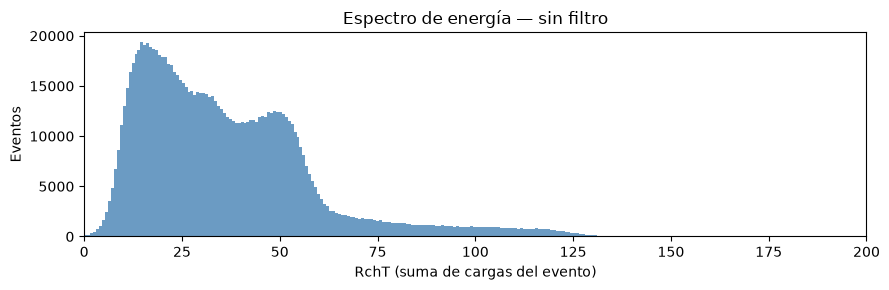

In [6]:
# calcular RchT para cada evento
rcht_all = np.array([c.sum() for c in all_charges], dtype=np.float32)

# ver el espectro antes de filtrar
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(rcht_all, bins=1000, color='steelblue', alpha=0.8)
ax.set_xlabel('RchT (suma de cargas del evento)')
ax.set_ylabel('Eventos')
ax.set_title('Espectro de energía — sin filtro')
plt.xlim([0,200])
plt.tight_layout()
plt.show()



## Activity and charge per sensor (this is what shows the dead channel)

El flood-map XY no muestra bien el sensor fallido porque la fórmula de gravedad
promedia posiciones. En cambio, contar activaciones o sumar cargas por sensor
muestra el canal muerto como un cero directo.

In [7]:
# constantes del detector
INACTIVE   = {1, 16, 18}
ACTIVE_CH  = sorted(set(range(64)) - INACTIVE)   # 61 canales
ICH_TO_IDX = {ich: i for i, ich in enumerate(ACTIVE_CH)}
IDX_TO_ICH = {i: ich for i, ich in enumerate(ACTIVE_CH)}
N = len(ACTIVE_CH)

# acumular estadísticas por sensor recorriendo todos los eventos
count_per_ch  = np.zeros(N, dtype=np.int64)     # cuántas veces disparó cada sensor
charge_per_ch = np.zeros(N, dtype=np.float64)   # suma total de carga de cada sensor

# all_charges[i] y all_channels[i] son los arrays del evento i
for charges, channels in zip(all_charges, all_channels):
    for rch, ich in zip(charges, channels):
        if ich in ICH_TO_IDX:           # ignorar canales 1,16,18 por si aparecen
            idx = ICH_TO_IDX[ich]       # convertir Ich físico a índice denso 0-60
            if rch > 0:                 # solo contar disparos reales (clip de negativos)
                count_per_ch[idx]  += 1
                charge_per_ch[idx] += rch

# carga media por sensor (solo sobre eventos donde disparó)
# np.divide con where evita dividir por cero: deja 0 donde count es 0
mean_charge = np.divide(charge_per_ch, count_per_ch,
                        out=np.zeros_like(charge_per_ch),
                        where=count_per_ch > 0)

# fracción de eventos donde disparó cada sensor
frac_active = count_per_ch / n_events

print(f'Eventos totales: {n_events:,}')
print(f'Sensor menos activo: idx={frac_active.argmin()}  '
      f'Ich={IDX_TO_ICH[frac_active.argmin()]}  '
      f'activo={frac_active.min()*100:.2f}%')

# listar los sensores con muy poca actividad (posibles muertos)
print('\nSensores con < 1% de actividad (posibles fallos):')
for idx in np.where(frac_active < 0.01)[0]:
    print(f'  idx={idx:2d}  Ich={IDX_TO_ICH[idx]:2d}  '
          f'activo={frac_active[idx]*100:.3f}%  count={count_per_ch[idx]}')

Eventos totales: 1,046,293
Sensor menos activo: idx=56  Ich=59  activo=0.33%

Sensores con < 1% de actividad (posibles fallos):
  idx=56  Ich=59  activo=0.331%  count=3465


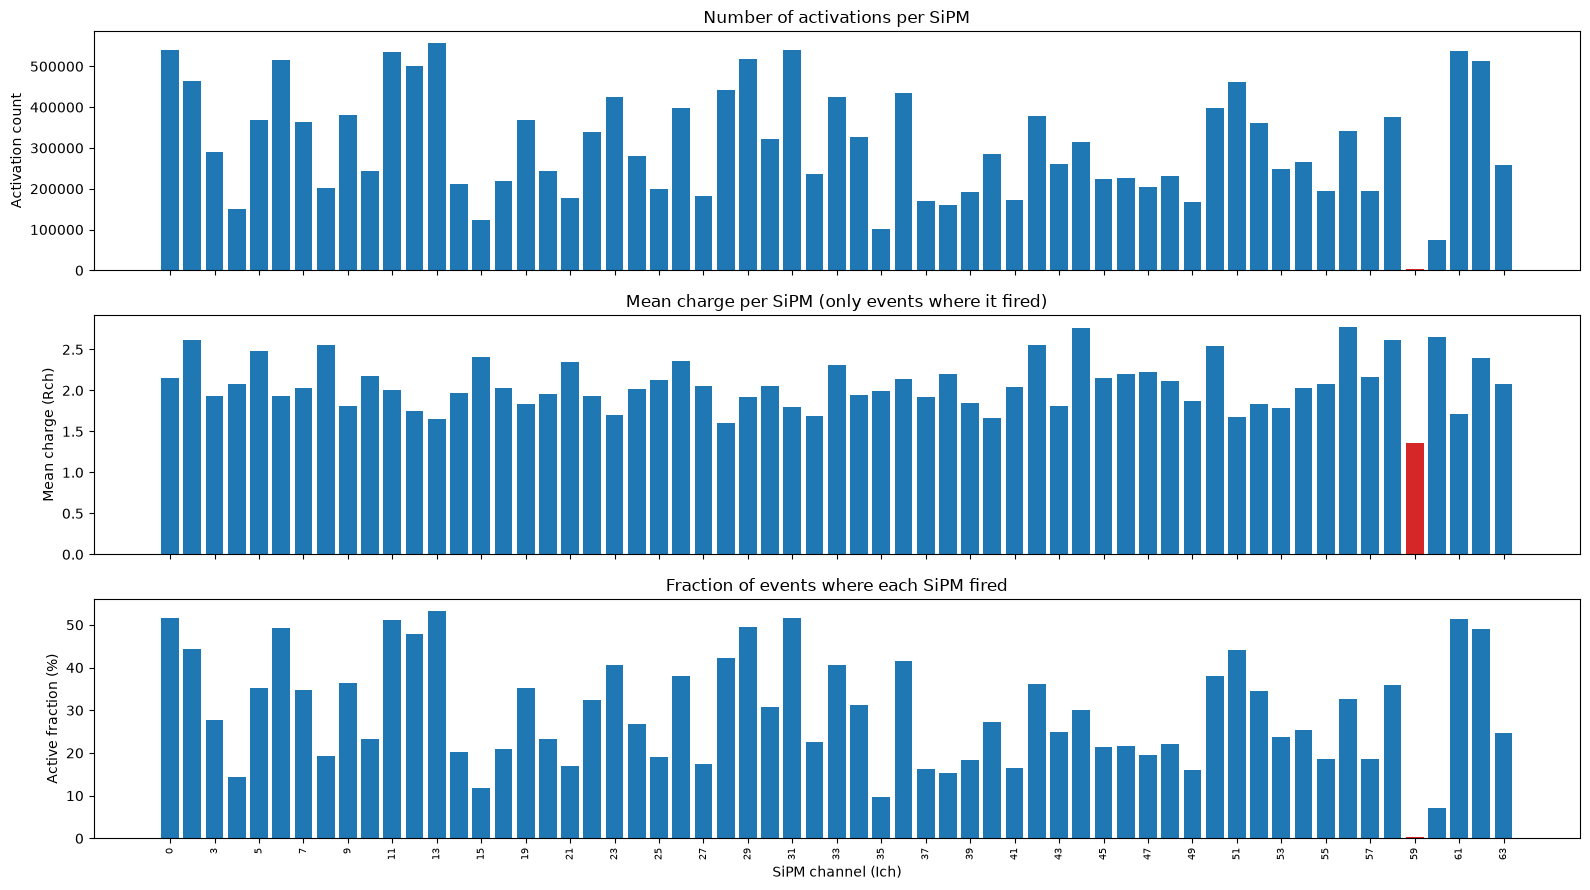

In [8]:
# bar plots: count, mean charge y fracción activa por sensor
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

x = np.arange(N)   # 0, 1, ..., 60

# detectar el sensor muerto para resaltarlo en rojo
dead_idx = np.where(frac_active < 0.01)[0]
colors = ['#d62728' if i in dead_idx else '#1f77b4' for i in range(N)]

# panel 1: número de activaciones
axes[0].bar(x, count_per_ch, color=colors)
axes[0].set_ylabel('Activation count')
axes[0].set_title('Number of activations per SiPM')

# panel 2: carga media
axes[1].bar(x, mean_charge, color=colors)
axes[1].set_ylabel('Mean charge (Rch)')
axes[1].set_title('Mean charge per SiPM (only events where it fired)')

# panel 3: fracción activa
axes[2].bar(x, frac_active * 100, color=colors)
axes[2].set_ylabel('Active fraction (%)')
axes[2].set_title('Fraction of events where each SiPM fired')
axes[2].set_xlabel('SiPM channel (Ich)')

# etiquetas del eje X con el Ich real
axes[2].set_xticks(x[::2])
axes[2].set_xticklabels([IDX_TO_ICH[i] for i in x[::2]], rotation=90, fontsize=7)

plt.tight_layout()
plt.show()

## Hexagonal map of activity (the dead sensor is obvious here)

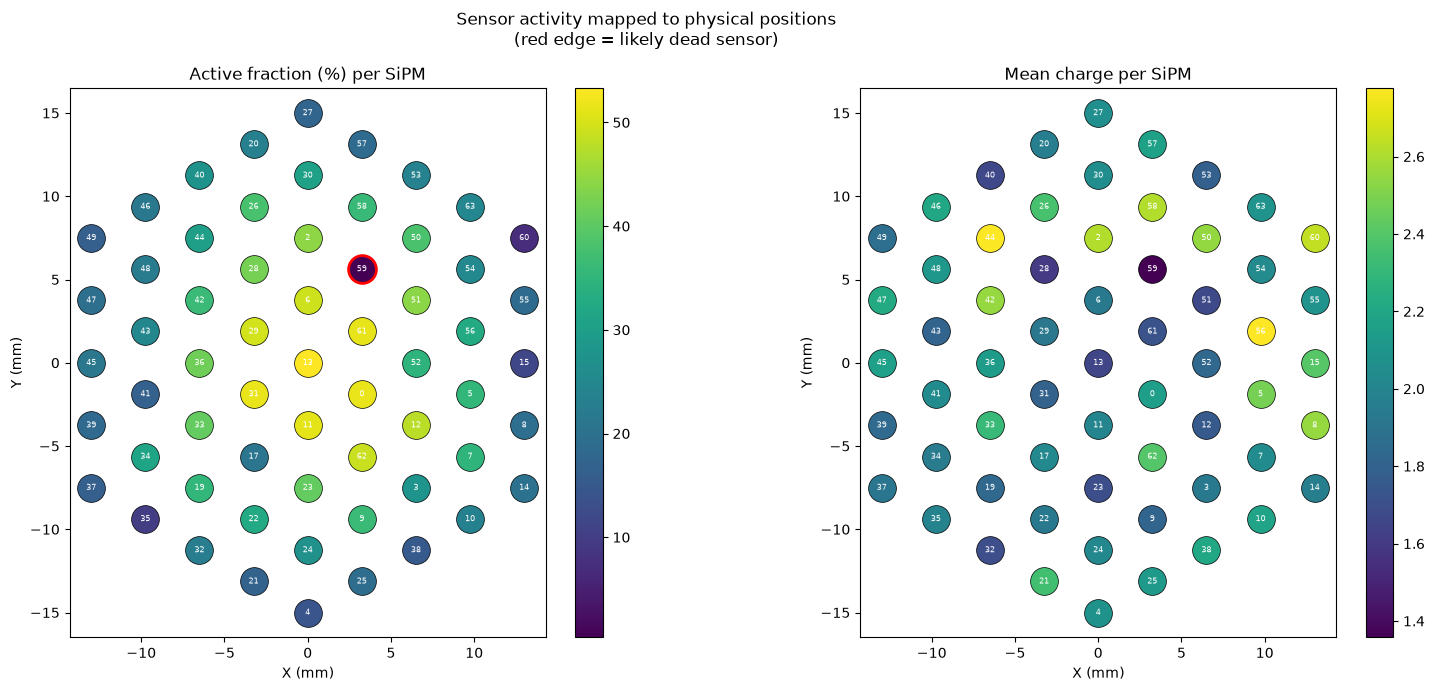

In [9]:
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# colorear cada sensor en su posición física real (del psipm.tsv)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, values, title in [
    (axes[0], frac_active * 100, 'Active fraction (%) per SiPM'),
    (axes[1], mean_charge,        'Mean charge per SiPM'),
]:
    norm = Normalize(vmin=values.min(), vmax=values.max())
    cmap = plt.get_cmap('viridis')

    for idx in range(N):
        ich = IDX_TO_ICH[idx]
        # usar la posición física real del sensor (x_pos, y_pos del psipm)
        cx, cy = x_pos[ich], y_pos[ich]
        ax.scatter(cx, cy, s=400, c=[cmap(norm(values[idx]))],
                   edgecolors='red' if values[idx] < values.max()*0.05 else 'black',
                   linewidths=2 if values[idx] < values.max()*0.05 else 0.5)
        ax.text(cx, cy, str(ich), ha='center', va='center',
                fontsize=6, color='white')

    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Sensor activity mapped to physical positions\n'
             '(red edge = likely dead sensor)', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
pos_x = np.zeros(n_events, dtype=np.float32)
pos_y = np.zeros(n_events, dtype=np.float32)

for i in range(n_events):
    charges  = all_charges[i]
    channels = all_channels[i]

    rch2 = charges ** 2          # pesos
    rcht = rch2.sum()            # suma total de pesos

    if rcht == 0:
        continue                 # evento sin carga (no debería ocurrir)

    x_sum = 0.0
    y_sum = 0.0
    for rch2_j, ich in zip(rch2, channels):
        if ich in x_pos:         # solo canales con posición conocida
            x_sum += rch2_j * x_pos[ich]
            y_sum += rch2_j * y_pos[ich]

    pos_x[i] = x_sum / rcht
    pos_y[i] = y_sum / rcht

print(f'pos_x shape: {pos_x.shape}   dtype: {pos_x.dtype}')
print(f'pos_y shape: {pos_y.shape}   dtype: {pos_y.dtype}')
print(f'X rango: [{pos_x.min():.2f}, {pos_x.max():.2f}] mm')
print(f'Y rango: [{pos_y.min():.2f}, {pos_y.max():.2f}] mm')
print()
print('Primeros 5 eventos → posición estimada:')
# for i in range(n_events):
#     print(f'  evento {i}: X={pos_x[i]:.2f} mm   Y={pos_y[i]:.2f} mm')

pos_x shape: (1046293,)   dtype: float32
pos_y shape: (1046293,)   dtype: float32
X rango: [-12.98, 12.98] mm
Y rango: [-14.90, 14.82] mm

Primeros 5 eventos → posición estimada:


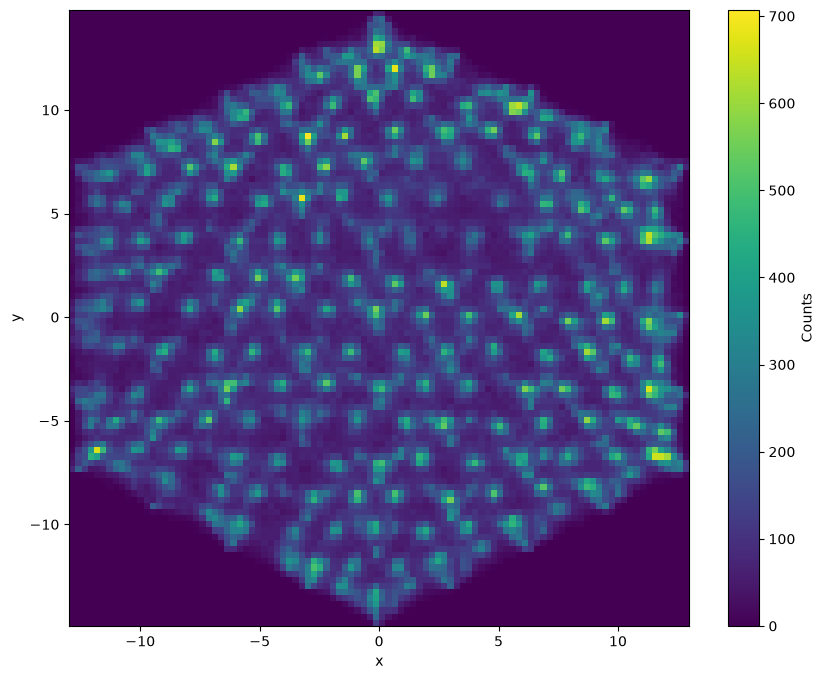

In [11]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.hist2d(pos_x, pos_y, bins=100)
plt.colorbar(label="Counts")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

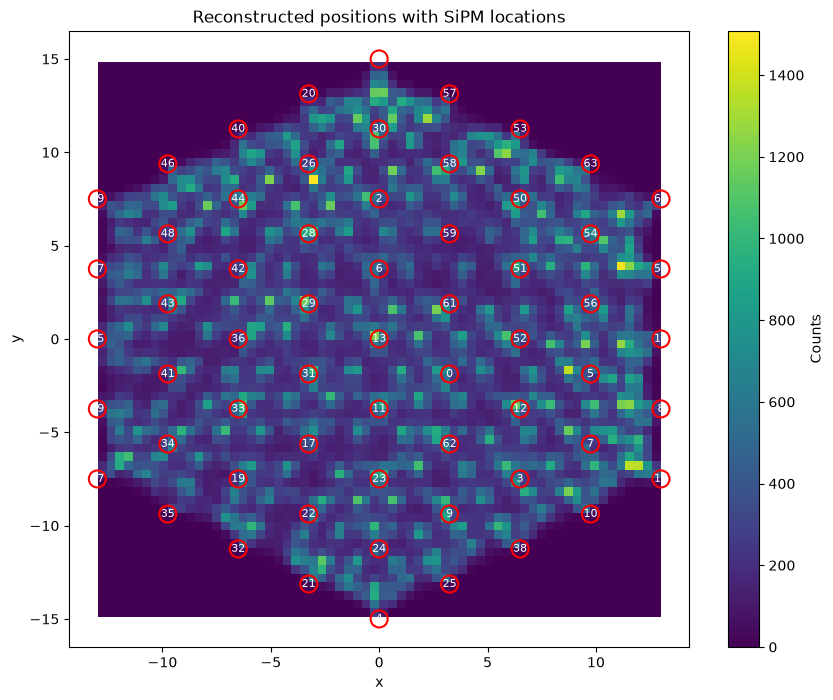

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Histograma de posiciones reconstruidas
h = ax.hist2d(pos_x, pos_y, bins=64)
plt.colorbar(h[3], ax=ax, label="Counts")

# Posiciones de los SiPMs
ax.scatter(
    list(x_pos_sorted.values()),
    list(y_pos_sorted.values()),
    facecolors="none",
    edgecolors="red",
    s=150,
    linewidths=1.5
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Reconstructed positions with SiPM locations")
for sensor in x_pos_sorted:
    ax.text(
        x_pos_sorted[sensor],
        y_pos_sorted[sensor],
        str(sensor),
        color="white",
        fontsize=8,
        ha="center",
        va="center"
    )
plt.show()

Radio del hexagono por sensor: 1.80 mm

Sensores con menor señal acumulada (camino B):
  idx=46  Ich=49  acc_norm=0.0040
  idx=57  Ich=60  acc_norm=0.0042
  idx=24  Ich=27  acc_norm=0.0042
  idx=32  Ich=35  acc_norm=0.0043
  idx=34  Ich=37  acc_norm=0.0048


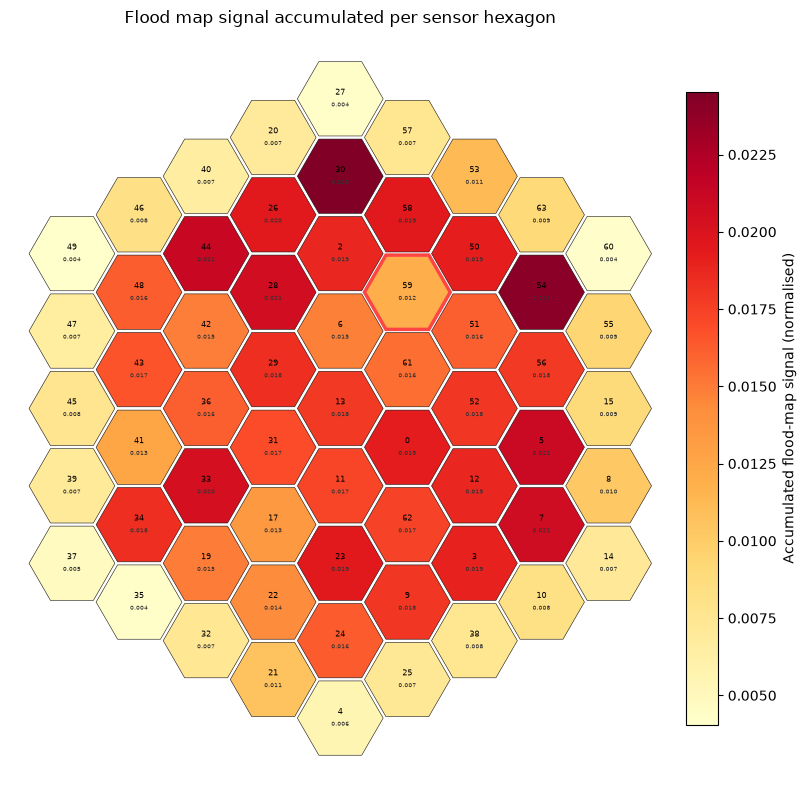

In [13]:
# ── Camino B: acumular el flood map XY dentro del hexagono de cada sensor ──
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.spatial import cKDTree

# arrays de posiciones de sensores en el mismo orden que ACTIVE_CH (0..60)
x_sipm_arr = np.array([x_pos[IDX_TO_ICH[i]] for i in range(N)])
y_sipm_arr = np.array([y_pos[IDX_TO_ICH[i]] for i in range(N)])

# ── radio: mitad de la distancia mediana entre sensores vecinos ──
pts = np.column_stack([x_sipm_arr, y_sipm_arr])
tree = cKDTree(pts)
dists, _ = tree.query(pts, k=2)          # k=2: vecino mas cercano (k=1 es si mismo)
nearest_dist = dists[:, 1]
radius = np.median(nearest_dist) / 2 * 0.96

print(f'Radio del hexagono por sensor: {radius:.2f} mm')

# ── flood map fino (histograma 2D de posiciones reconstruidas) ──
bins = 150
pad = 0.5
xr = [x_sipm_arr.min()-pad, x_sipm_arr.max()+pad]
yr = [y_sipm_arr.min()-pad, y_sipm_arr.max()+pad]
h, xe, ye = np.histogram2d(pos_x, pos_y, bins=bins, range=[xr, yr])

# centros de los bins (no los bordes)
xc = (xe[:-1] + xe[1:]) / 2
yc = (ye[:-1] + ye[1:]) / 2
# meshgrid con indexing='ij' -> XX[i,j]=xc[i], YY[i,j]=yc[j], coincide con h[i,j]
XX, YY = np.meshgrid(xc, yc, indexing='ij')

# ── para cada sensor, sumar las cuentas del histograma dentro de su circulo ──
acc = np.zeros(N)
for k in range(N):
    sx, sy = x_sipm_arr[k], y_sipm_arr[k]
    dist = np.sqrt((XX - sx)**2 + (YY - sy)**2)
    mask = dist <= radius
    acc[k] = h[mask].sum()

acc_norm = acc / n_events   # normalizar por nº de eventos

print('\nSensores con menor señal acumulada (camino B):')
worst = np.argsort(acc_norm)[:5]
for k in worst:
    print(f'  idx={k:2d}  Ich={IDX_TO_ICH[k]:2d}  acc_norm={acc_norm[k]:.4f}')

# ── plot: mapa hexagonal con la señal acumulada ──
fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor('white')        # antes '#0d1117'
ax.set_facecolor('white')               # antes '#0d1117'
ax.axis('off')
ax.set_title('Flood map signal accumulated per sensor hexagon',
              color='black', pad=10)     # antes '#e6edf3'
norm = Normalize(vmin=acc_norm.min(), vmax=acc_norm.max())
cmap_obj = plt.get_cmap('YlOrRd')

for idx in range(N):
    ich = IDX_TO_ICH[idx]
    cx, cy = x_sipm_arr[idx], y_sipm_arr[idx]
    color = cmap_obj(norm(acc_norm[idx]))
    # resaltar en rojo los mismos sospechosos detectados en el camino A (dead_idx)
    is_suspect = idx in dead_idx
    edge = '#ff4444' if is_suspect else '#111'
    lw   = 2.5 if is_suspect else 0.4
    ax.add_patch(mpatches.RegularPolygon(
        (cx, cy), numVertices=6, radius=radius/np.cos(np.pi/6),
        orientation=np.pi/6, facecolor=color, edgecolor=edge, linewidth=lw))
    ax.text(cx, cy+0.3, str(ich), ha='center', va='center',
            fontsize=5.5, color='black')
    ax.text(cx, cy-0.3, f'{acc_norm[idx]:.3f}', ha='center', va='center',
            fontsize=4, color='#333')

ax.set_xlim(x_sipm_arr.min()-3, x_sipm_arr.max()+3)
ax.set_ylim(y_sipm_arr.min()-3, y_sipm_arr.max()+3)
ax.set_aspect('equal')
sm = ScalarMappable(cmap=cmap_obj, norm=norm); sm.set_array([])
plt.colorbar(sm, ax=ax, label='Accumulated flood-map signal (normalised)',
              fraction=0.04, pad=0.02)

plt.tight_layout()
plt.show()

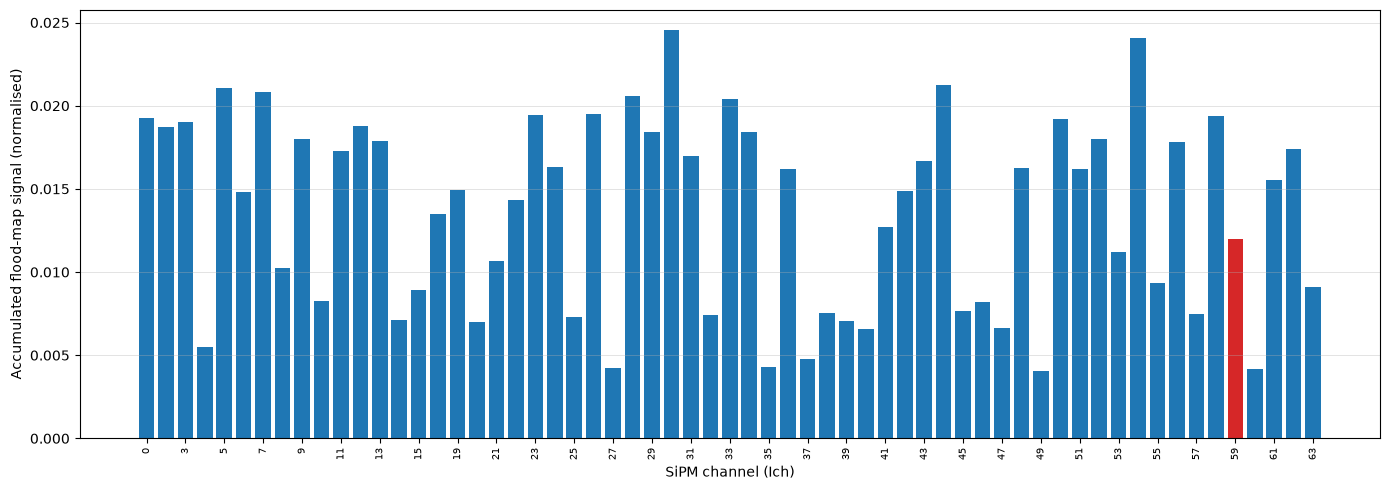

In [14]:
# ── Camino B en 1D: barplot de la señal acumulada por sensor (61 bins) ──
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('white')

x = np.arange(N)   # 0, 1, ..., 60

# color rojo en los sensores que el camino A marcó como muertos, azul el resto
colors = ['#d62728' if i in dead_idx else '#1f77b4' for i in range(N)]

ax.bar(x, acc_norm, color=colors)

ax.set_xlabel('SiPM channel (Ich)')
ax.set_ylabel('Accumulated flood-map signal (normalised)')

# etiquetas del eje X con el Ich real, mismo paso en ticks y labels
step = 2
ax.set_xticks(x[::step])
ax.set_xticklabels([IDX_TO_ICH[i] for i in x[::step]], rotation=90, fontsize=7)

ax.grid(axis='y', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

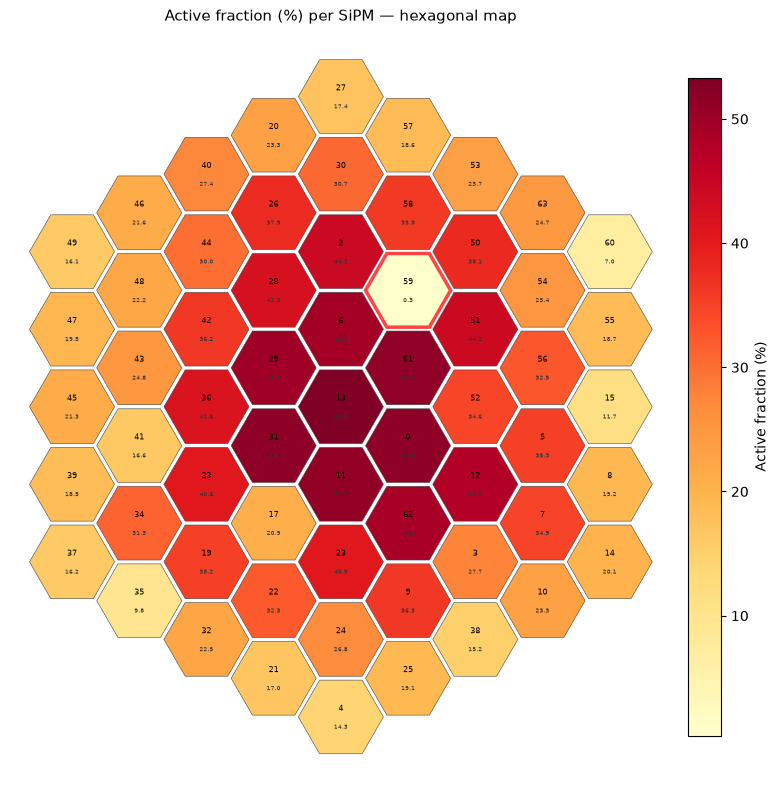

In [15]:
# ── Mapa hexagonal de fracción de activación (camino A sobre hexágonos) ──
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.spatial import cKDTree

# arrays de posiciones en orden denso 0..60
x_sipm_arr = np.array([x_pos[IDX_TO_ICH[i]] for i in range(N)])
y_sipm_arr = np.array([y_pos[IDX_TO_ICH[i]] for i in range(N)])

# distancia entre sensores vecinos para dimensionar los hexágonos
pts = np.column_stack([x_sipm_arr, y_sipm_arr])
tree = cKDTree(pts)
dists, _ = tree.query(pts, k=2)
spacing = np.median(dists[:, 1])              # distancia mediana al vecino
hex_radius = spacing / np.sqrt(3) * 0.95      # centro a vértice, teselado sin solape

# valor a pintar: fracción de activación en % (del array crudo, NO del flood map)
values = frac_active * 100

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_facecolor('white')
ax.axis('off')
ax.set_title('Active fraction (%) per SiPM — hexagonal map',
             color='black', fontsize=11, pad=10)

norm = Normalize(vmin=values.min(), vmax=values.max())
cmap_obj = plt.get_cmap('YlOrRd')

for idx in range(N):
    ich = IDX_TO_ICH[idx]
    cx, cy = x_sipm_arr[idx], y_sipm_arr[idx]
    color = cmap_obj(norm(values[idx]))
    # borde rojo en los sensores que el camino A marcó como muertos
    is_suspect = idx in dead_idx
    edge = '#ff4444' if is_suspect else '#444'
    lw   = 2.5 if is_suspect else 0.4
    ax.add_patch(mpatches.RegularPolygon(
        (cx, cy), numVertices=6, radius=hex_radius,
        orientation=np.pi/6, facecolor=color, edgecolor=edge, linewidth=lw))
    ax.text(cx, cy+0.4, str(ich), ha='center', va='center',
            fontsize=5.5, color='black')
    ax.text(cx, cy-0.5, f'{values[idx]:.1f}', ha='center', va='center',
            fontsize=4, color='#333')

ax.set_xlim(x_sipm_arr.min()-3, x_sipm_arr.max()+3)
ax.set_ylim(y_sipm_arr.min()-3, y_sipm_arr.max()+3)
ax.set_aspect('equal')
sm = ScalarMappable(cmap=cmap_obj, norm=norm); sm.set_array([])
plt.colorbar(sm, ax=ax, label='Active fraction (%)', fraction=0.04, pad=0.02)

plt.tight_layout()
plt.show()

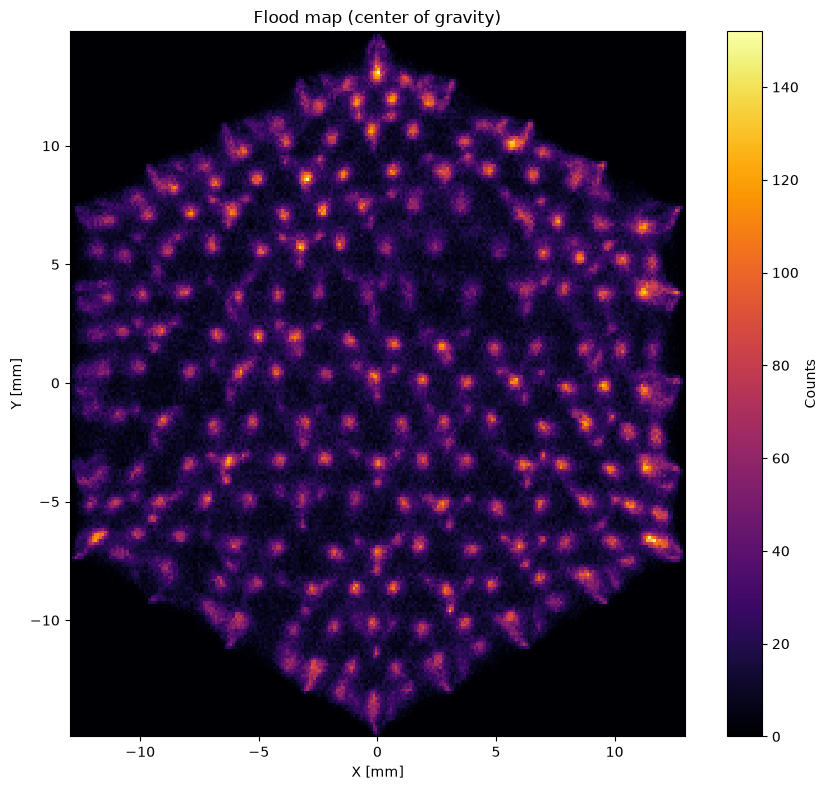

In [16]:
# ── Flood map 2D de alta resolución ──
fig, ax = plt.subplots(figsize=(9, 8))
ax.set_facecolor('white')

bins = 250   # sube esto para más detalle (200-300 va bien)
h = ax.hist2d(pos_x, pos_y, bins=bins, cmap='inferno')
plt.colorbar(h[3], ax=ax, label='Counts')

ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.set_title('Flood map (center of gravity)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

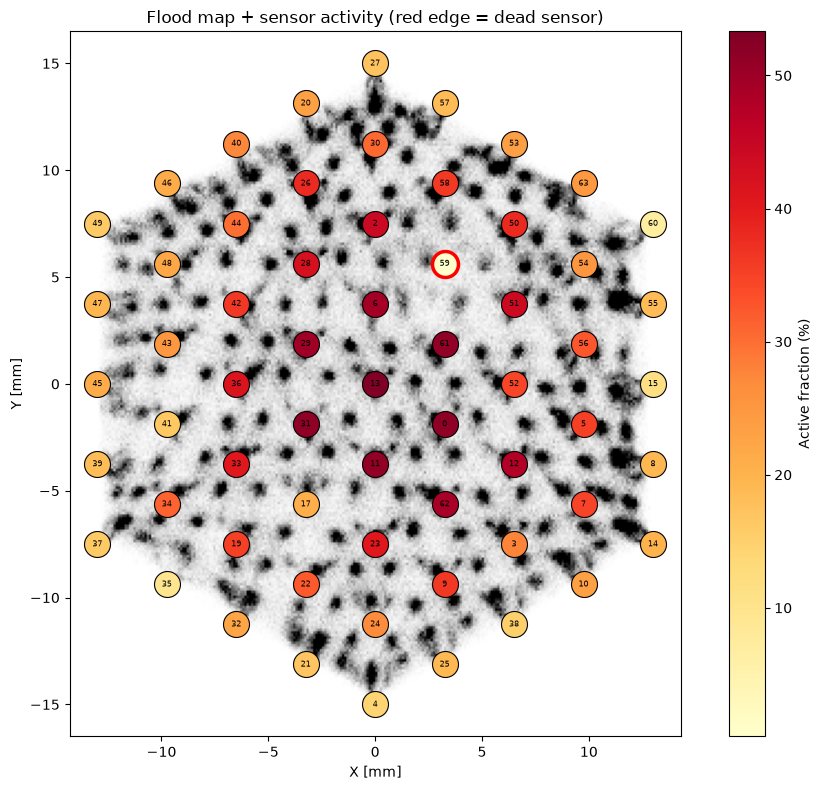

In [17]:
# ── Flood map 2D + sensores coloreados por fracción de activación ──
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('white')

# fondo: el flood map en escala de grises para que los sensores resalten
bins = 250
h, xe, ye = np.histogram2d(pos_x, pos_y, bins=bins)
im = ax.imshow(h.T, origin='lower',
               extent=[xe[0], xe[-1], ye[0], ye[-1]],
               aspect='equal', cmap='Greys',
               vmax=np.percentile(h[h > 0], 95))   # recorta picos para ver el patrón

# encima: cada sensor como círculo coloreado por su fracción de activación
values = frac_active * 100
norm = Normalize(vmin=values.min(), vmax=values.max())
cmap_obj = plt.get_cmap('YlOrRd')

for idx in range(N):
    ich = IDX_TO_ICH[idx]
    cx, cy = x_pos[ich], y_pos[ich]
    is_suspect = idx in dead_idx
    ax.scatter(cx, cy, s=350, c=[cmap_obj(norm(values[idx]))],
               edgecolors='red' if is_suspect else 'black',
               linewidths=2.5 if is_suspect else 0.8, zorder=3)
    ax.text(cx, cy, str(ich), ha='center', va='center',
            fontsize=6, color='black', zorder=4)

ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.set_title('Flood map + sensor activity (red edge = dead sensor)')

sm = ScalarMappable(cmap=cmap_obj, norm=norm); sm.set_array([])
plt.colorbar(sm, ax=ax, label='Active fraction (%)')
plt.tight_layout()
plt.show()


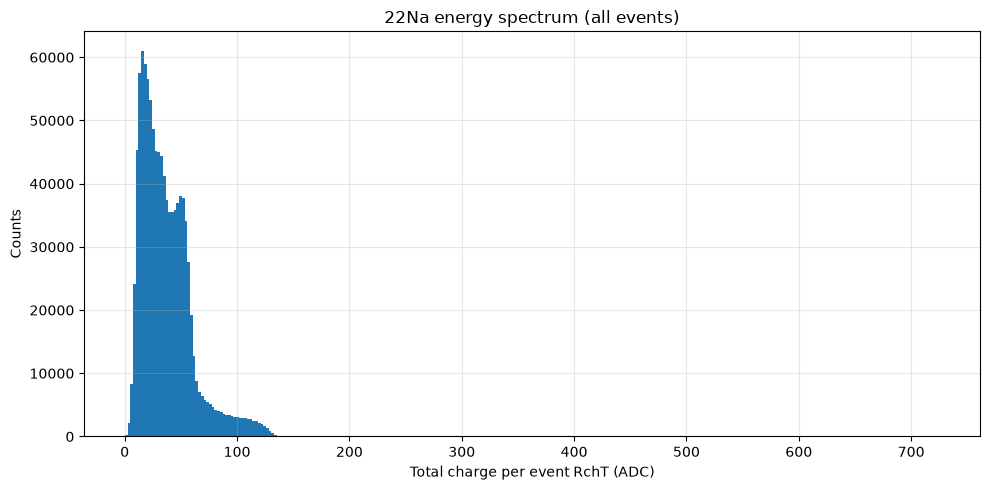

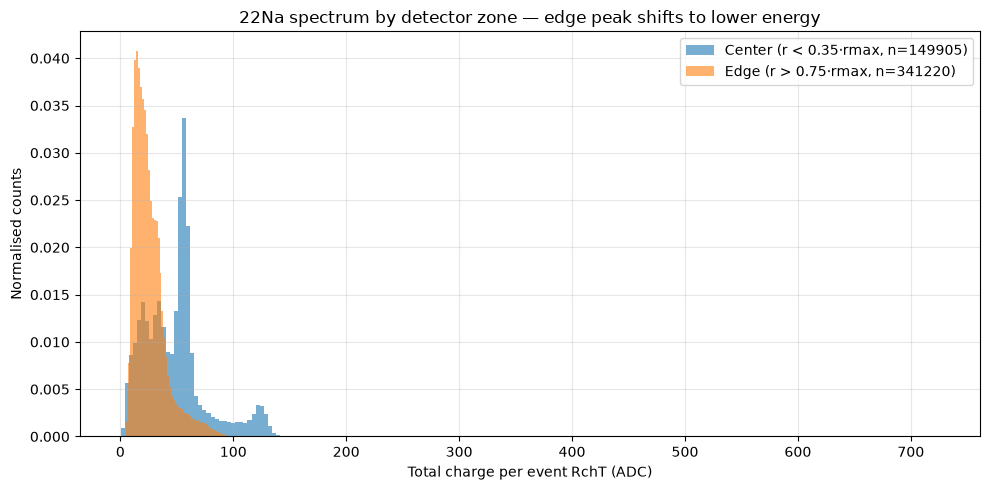

In [18]:
# ── Espectro de energía 22Na: global y por zonas (centro vs borde) ──
import numpy as np
import matplotlib.pyplot as plt

# RchT = suma de carga de todos los sensores en cada evento (clipeando negativos)
# all_charges es tu lista de arrays de carga por evento
rcht = np.array([np.clip(c, 0, None).sum() for c in all_charges])

# ── Plot 1: espectro global (todos los eventos) ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rcht, bins=300, color='#1f77b4', edgecolor='none')
ax.set_xlabel('Total charge per event RchT (ADC)')
ax.set_ylabel('Counts')
ax.set_title('22Na energy spectrum (all events)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 2: espectro por zona del detector (centro vs borde) ──
# distancia de la posición reconstruida al centro del detector
r = np.sqrt(pos_x**2 + pos_y**2)

# define zonas por radio: ajusta los umbrales según el rango de tus posiciones
r_max = r.max()
center_mask = r < 0.35 * r_max     # eventos reconstruidos cerca del centro
edge_mask   = r > 0.75 * r_max     # eventos reconstruidos cerca del borde

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rcht[center_mask], bins=200, alpha=0.6,
        color='#1f77b4', label=f'Center (r < 0.35·rmax, n={center_mask.sum()})',
        density=True)
ax.hist(rcht[edge_mask], bins=200, alpha=0.6,
        color='#ff7f0e', label=f'Edge (r > 0.75·rmax, n={edge_mask.sum()})',
        density=True)
ax.set_xlabel('Total charge per event RchT (ADC)')
ax.set_ylabel('Normalised counts')
ax.set_title('22Na spectrum by detector zone — edge peak shifts to lower energy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Matriz densa: (1046293, 61), no-ceros por evento (media): 17.9
Referencia (mediana de picos): 5.0 ADC
Factores: min=0.75, max=2.91
Canales con mayor corrección (los de borde deberían salir aquí):
  idx=56 Ich=59  pico=1.7  factor=2.91
  idx=18 Ich=21  pico=3.8  factor=1.30
  idx=29 Ich=32  pico=3.9  factor=1.28
  idx=34 Ich=37  pico=4.0  factor=1.26
  idx=45 Ich=48  pico=4.0  factor=1.25
  idx=33 Ich=36  pico=4.0  factor=1.24
  idx=54 Ich=57  pico=4.1  factor=1.22
  idx= 3 Ich= 4  pico=4.1  factor=1.21


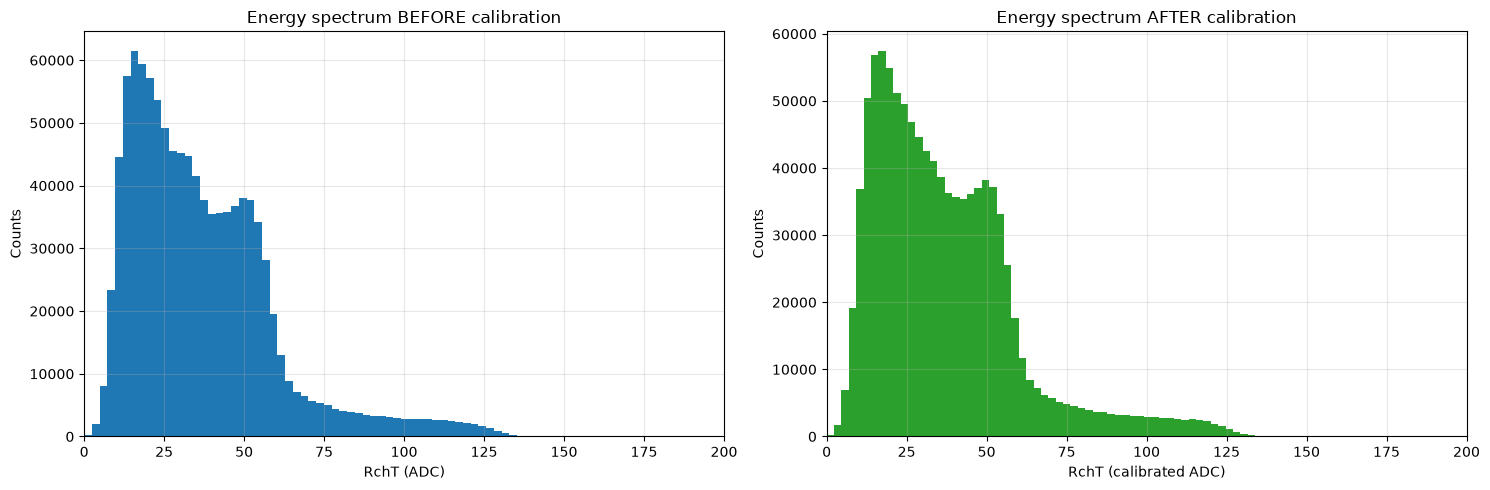

In [25]:
# ── Calibración en energía por canal: alinear el fotopico de cada SiPM ──
import numpy as np
import matplotlib.pyplot as plt


# ── Construir matriz densa X (n_events, 61) desde all_charges / all_channels ──
import numpy as np

X = np.zeros((n_events, N), dtype=np.float32)

for i in range(n_events):
    chans   = all_channels[i]          # Ich de los sensores que dispararon
    charges = all_charges[i]           # sus cargas
    for ich, q in zip(chans, charges):
        if ich in ICH_TO_IDX:          # ignora canales inactivos (1,16,18) por si acaso
            X[i, ICH_TO_IDX[ich]] = q

X = np.clip(X, 0, None)                # negativos del pedestal a cero
print(f'Matriz densa: {X.shape}, no-ceros por evento (media): {(X>0).sum(axis=1).mean():.1f}')
# X = matriz densa de cargas (n_events, 61), negativos ya clipeados a 0
# Si trabajas con all_charges/all_channels, dime y la construyo

# ── Paso 1: localizar el fotopico de cada canal ──
# buscamos el máximo del histograma de cada canal, IGNORANDO la zona de ruido baja
peak_pos = np.zeros(N)        # posición ADC del fotopico de cada canal
nbins = 150
noise_cut_frac = 0.15         # ignora el 15% inferior del rango (zona de ruido)

for k in range(N):
    vals = X[:, k]
    vals = vals[vals > 0]     # solo eventos donde el canal disparó
    if len(vals) < 100:       # canal casi muerto, sin estadística
        peak_pos[k] = np.nan
        continue
    counts, edges = np.histogram(vals, bins=nbins)
    centers = (edges[:-1] + edges[1:]) / 2
    # ignorar la zona baja (ruido): solo buscar pico por encima del corte
    cut = noise_cut_frac * centers.max()
    search = centers > cut
    # el fotopico es el máximo de cuentas en la zona de búsqueda
    idx_peak = np.argmax(counts[search])
    peak_pos[k] = centers[search][idx_peak]

# ── Paso 2: elegir referencia y calcular factores ──
# referencia = mediana de los picos (un valor central robusto)
reference = np.nanmedian(peak_pos)
factors = reference / peak_pos
factors[np.isnan(factors)] = 1.0   # canales sin pico: no tocar

print(f'Referencia (mediana de picos): {reference:.1f} ADC')
print(f'Factores: min={np.nanmin(factors):.2f}, max={np.nanmax(factors):.2f}')
print('Canales con mayor corrección (los de borde deberían salir aquí):')
for k in np.argsort(factors)[::-1][:8]:
    print(f'  idx={k:2d} Ich={IDX_TO_ICH[k]:2d}  pico={peak_pos[k]:.1f}  factor={factors[k]:.2f}')

# ── Paso 3: aplicar la calibración ──
X_cal = X * factors[np.newaxis, :]   # cada columna (canal) por su factor

# ── Comparar el espectro global antes y después ──
rcht_raw = X.sum(axis=1)
rcht_cal = X_cal.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(rcht_raw, bins=300, color='#1f77b4')
axes[0].set_title('Energy spectrum BEFORE calibration')
axes[0].set_xlabel('RchT (ADC)'); axes[0].set_ylabel('Counts')
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 200)   # <- límite X

axes[1].hist(rcht_cal, bins=300, color='#2ca02c')
axes[1].set_title('Energy spectrum AFTER calibration')
axes[1].set_xlabel('RchT (calibrated ADC)'); axes[1].set_ylabel('Counts')
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 200)   # <- límite X

plt.tight_layout()
plt.show()